In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy import stats




df = pd.read_csv('data-69d3709338fdb705334215.csv')

df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,6,1,0,0,0,0,0,1,0,Spain
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,5,0,0,0,0,1,1,0,Canada
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,5,2,0,0,0,0,0,0,0,USA
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/2014,0,10,...,2,7,0,0,0,0,0,0,0,Australia
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/2014,0,6,...,2,7,1,0,0,0,0,1,0,Spain


## Étape 1 : Analyse Exploratoire des Données (Python)

In [7]:
#Afficher les noms des colonnes
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', ' Income ',
       'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntBakedProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='str')

In [8]:
#Comprendre la structure des données
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4    Income              2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntBakedProds        2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [9]:
#Analyser les statistiques descriptives des variables numériques
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
#Vérifier les valeurs manquantes
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
 Income                24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntBakedProds           0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

In [11]:
#Vérification des doublons
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns = df.columns.str.strip()

## Visualisation des données

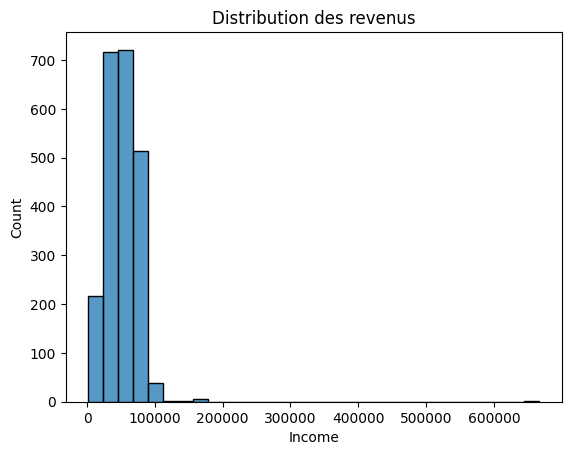

In [23]:
sns.histplot(df["Income"], bins=30)
plt.title("Distribution des revenus")
plt.show()

La distribution des revenus est asymétrique à droite, ce qui indique que la majorité des clients ont un revenu moyen, avec quelques clients ayant des revenus très élevés.

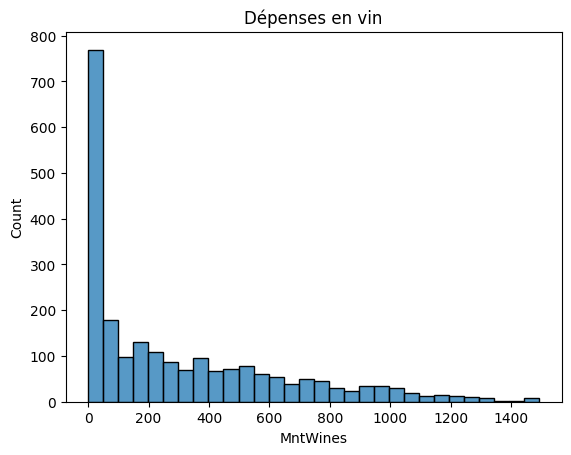

In [14]:
sns.histplot(df["MntWines"], bins=30)
plt.title("Dépenses en vin")
plt.show()

La majorité des clients dépensent peu en vin, tandis qu’un petit groupe dépense des montants élevés, ce qui montre une concentration des ventes sur certains clients.

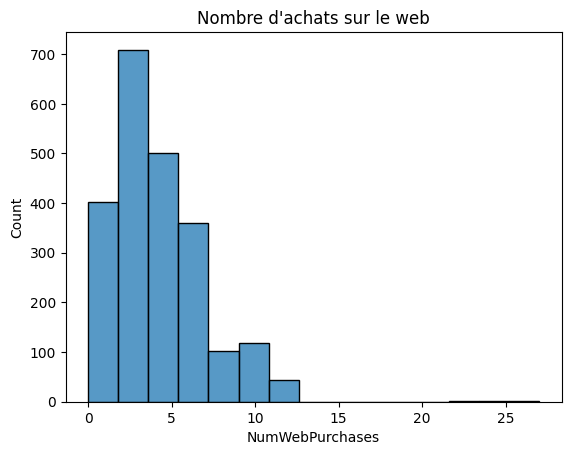

In [15]:
sns.histplot(df["NumWebPurchases"], bins=15)
plt.title("Nombre d'achats sur le web")
plt.show()

La plupart des clients effectuent un faible nombre d’achats en ligne, ce qui indique un comportement d’achat modéré sur le canal web.

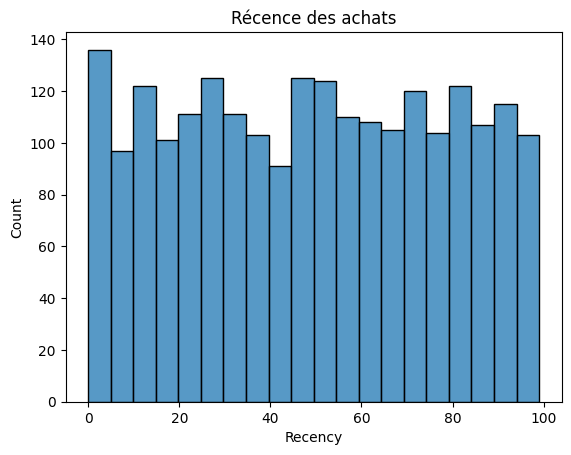

In [16]:
sns.histplot(df["Recency"], bins=20)
plt.title("Récence des achats")
plt.show()

La distribution de la récence montre que les clients ont des comportements variés, certains ayant effectué des achats récents tandis que d’autres sont inactifs depuis plus longtemps.

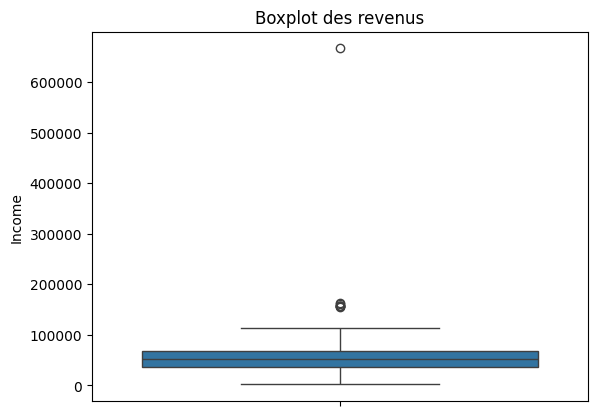

In [17]:
sns.boxplot(df["Income"])
plt.title("Boxplot des revenus")
plt.show()

Le boxplot met en évidence la présence de valeurs aberrantes correspondant à des clients à revenus très élevés. La majorité des clients se situe dans une plage de revenus modérée.

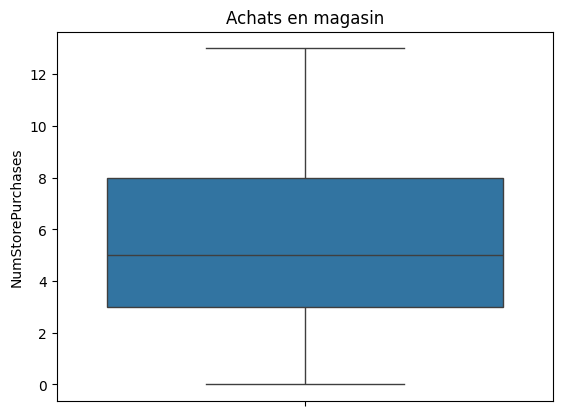

In [18]:
sns.boxplot(df["NumStorePurchases"])
plt.title("Achats en magasin")
plt.show()

La majorité des clients effectue un nombre modéré d’achats en magasin. Quelques valeurs élevées indiquent l’existence de clients très actifs.

## Étape 2 : Tests Statistiques

In [19]:
#test t-test comparasion 2 groupe 
group0 = df[df["Response"] == 0]["MntWines"]
group1 = df[df["Response"] == 1]["MntWines"]
t_stat, p_value = stats.ttest_ind(group0, group1)
print(f"T-stat : {t_stat:.3f}")
print(f"P-value : {p_value:.35f}")

if p_value < 0.05:
    print("Différence significative — Response influence TotalSpend")
else:
    print("Pas de différence significative")

T-stat : -12.072
P-value : 0.00000000000000000000000000000001493
Différence significative — Response influence TotalSpend


In [20]:
#test chi2 pour deux variable catergorielle
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Marital_Status"], df["Response"])
chi2, p_value, dof, expected = chi2_contingency(table)

print(f"Chi2 : {chi2:.3f}")
print(f"P-value : {p_value:.25f}")
print(f"Degrés de liberté : {dof}")

if p_value < 0.05:
    print("Relation significative entre Marital status et Response")

Chi2 : 54.242
P-value : 0.0000000021067470540907000
Degrés de liberté : 7
Relation significative entre Marital status et Response
